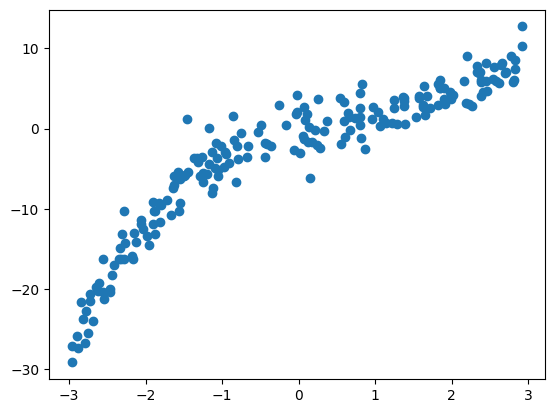

In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

data_df = pd.read_csv('../datasets/nonlinear_data.csv')
x = data_df[['X']].values
y = data_df[['y']].values
plt.scatter(data_df['X'], data_df['y'])  #직선인지 곡선인지
plt.show()

In [6]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
#데이터 스케일링 + 다형변환 + 선형회귀 모델
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures()), #곡선으로 표현
    ('ridge', Ridge(random_state=42)),
])
param_grid = {
    'poly__degree':[1,2,3,4,5,8],
    'ridge__alpha':[0.001,0.01,0.1,1.0,10.0,100.0] #작으면 규제 없음
}
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
grid.fit(x, y)
print(f'최적 하이퍼파라미터 조합:{grid.best_params_}')


최적 하이퍼파라미터 조합:{'poly__degree': 4, 'ridge__alpha': 1.0}


In [7]:
from sklearn.metrics import mean_squared_error, r2_score
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
#최적의 모델
best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)
print(f'test mse:{mse:.4f}')
print(f'test r2:{r2:.4f}')

test mse:4.2690
test r2:0.9280


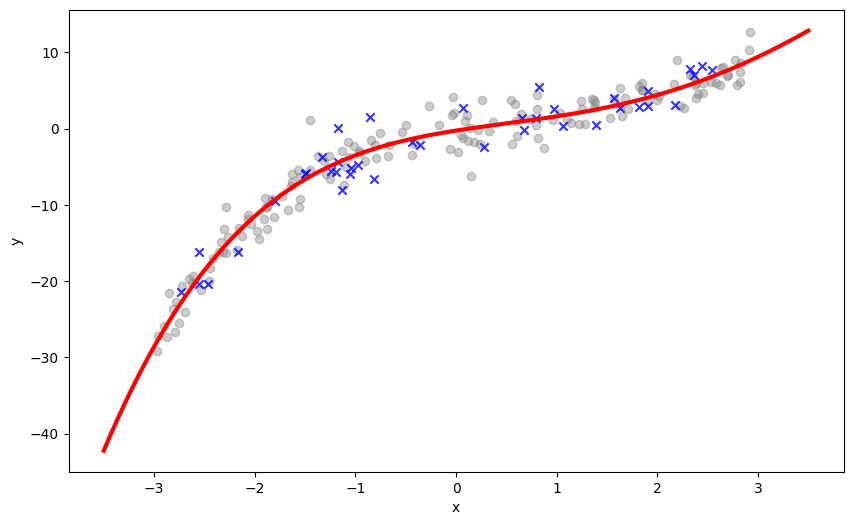

In [9]:
#시각화
x_plot = np.linspace(-3.5, 3.5, 200).reshape(-1,1)
plt.figure(figsize=(10,6))
plt.scatter(x_train, y_train, color='gray', alpha=0.4, label='train data')
plt.scatter(x_test, y_test, color='blue', alpha=0.8, label='test data', marker='x')
y_plot_best = best_model.predict(x_plot)
plt.plot(x_plot, y_plot_best, color='red', linewidth=3, label=f'(deg{grid.best_params_['poly__degree']}')
plt.xlabel('x')
plt.ylabel('y')
plt.show()